# Setting Up Local LLM

### Ollama + Continue Extension in VS Code

## Agenda

1. Ollama
1. Continue
1. Local Network Deployment

## Ollama Installation

* Check and update NVIDIA driver version
* Download [Ollama for Windows](https://ollama.com/download/windows) and install
    * Once installed, it registers as a background service and runs automatically
* Configure Ollama to pull models into D drive (optional)
* See [my technical site](https://fixedincome2025.readthedocs.io/en/latest/I_local_llm.html) for more details

### Update NVIDIA Driver Version

* As of July 2026, Ollama [requires](https://docs.ollama.com/windows#system-requirements) NVIDIA 551.61 or newer drivers if you have an NVIDIA card
* In `cmd`: `nvidia-smi` or Start > NVIDIA Control Panel > System Information (bottom left corner)
* Update Windows: Start > Settings > Windows Update
* Update driver version: Download and install from [Manual Driver Search](https://www.nvidia.com/en-us/software/nvidia-app/)
    * **Updating driver will fail if you have GTX 10 series on Windows 11 25H2.** They have conflict
        * If that's your case, download NVIDIA GeForce Hotfix Driver 581.94 (NVIDIA's hotfix for 24H2/25H2)
        * Install the driver only, not NVIDIA App, as Ollama only needs the driver, and there could be conflict again
    * Example (failed):
        * Product Category: GeForce
        * Product Series: GeForce 10 Series
        * Product: GeForce GTX 1080
        * Operating System: Windows 11
        * Find > Download Studio version
            * Game Ready is the latest fastest version, while Studio version is a recent stable version

### Download and Install [Ollama for Windows](https://ollama.com/download/windows) 

### Configure Model Location (Optional)

* By default, Ollama pulls models into `C:\Users\scott\.ollama\models\blobs`, not an issue if you have huge C drive
* To change the model location, set **system** env variable `OLLAMA_MODELS` to, say `D:\OllamaModels`
    * System, not user. System env variables are under user
    * Delete `C:\Users\scott\.ollama\models\` if it already exists
* Run `ollama pull tinyllama` in `cmd` to test if it's pulled into D drive. This is a tiny model

## Ollama Commands

* Pull model, but not run
    * `ollama pull qwen2.5-coder:7b`
    * `ollama pull qwen2.5-coder:1.5b`

* Run model
    * `ollama run qwen2.5-coder:7b`
    * If it's the first time you use a specific model, it takes a few minutes to pull it
    * When you see the `>>>` prompt just say something like "code me a python quick sort"
    * To quit: `/exit`, `/quit` or `Ctrl-D`

* Search model tags: `ollama search qwen3`
* Delete downloaded models
    * `ollama list`: Check existing models
    * `ollama rm <YOUR_LLM>`
* Full list of Ollama commands: `ollama --help`
* Quit Ollama: Right click on the bottom right corner ollama icon in windows

## Best Open-Weights LLMs (July 2026)

* `qwen3:30b`: Optimized for coding, repository-level reasoning and local debugging
* `deepseek-r1:70b`: Math and logical reasoning; utilizes high-RAM capacity for complex chain-of-thought

## Behind the Scenes

* Ollama is an server running on http://localhost:11434/ which accepts REST API
* Example endpoints:
    * http://localhost:11434/api/version   GET
    * http://localhost:11434/api/generate  POST
    * http://localhost:11434/api/chat      POST
* VS Code extensions can package user's prompt, send as a payload with rest call to Ollama, and get response

## Continue

* Install VS Code extension: **Continue - open-source AI code agent**
* Right click > Move To > Secondary Side Bar (optional)
* Open settings > Configs > click on Main Config
    * It will open `C:\Users\scott\.continue\config.yaml`
    * Copy and paste the config

* Without `capabilities: []` in the config, the agent will spit out tool-calling JSON, not code
* `systemMessage` is for AI, not users

```yaml
name: Local Config
version: 0.0.1
schema: v1
models:
  - name: Qwen 7B Coder
    provider: ollama
    model: qwen2.5-coder:7b
    # apiBase: "http://10.0.0.100"  # required for local network deployment
    roles:
      - chat
      - edit
    capabilities: []
    systemMessage: "You are an expert developer. Respond ONLY with raw code blocks or direct text explanations. NEVER output tool-calling JSON or wrap your entire response in a JSON object."
  - name: Qwen 1.5B Autocomplete
    provider: ollama
    model: qwen2.5-coder:1.5b
    # apiBase: "http://10.0.0.100"  # required for local network deployment
    roles:
      - autocomplete
```

## Local Network Deployment

* Mac Studio server farm
    * Apple machines have CPU and GPU share RAM
    * **Apple Mac Studio with M3 Ultra**, which comes with 96, 256 or 516 GB RAMs
    * 80b models require 96 GB RAM
    * 120b models require 256 GB RAM
    * 4 server machines are enough for 25 people

* Server machine setup
    * Each machine has its own Ollama running, exposed through NGINX
    * NGINX set up on two of the 4: Central server and backup server
    * On each machine, run `launchctl setenv OLLAMA_HOST "0.0.0.0:11434"` and reboot

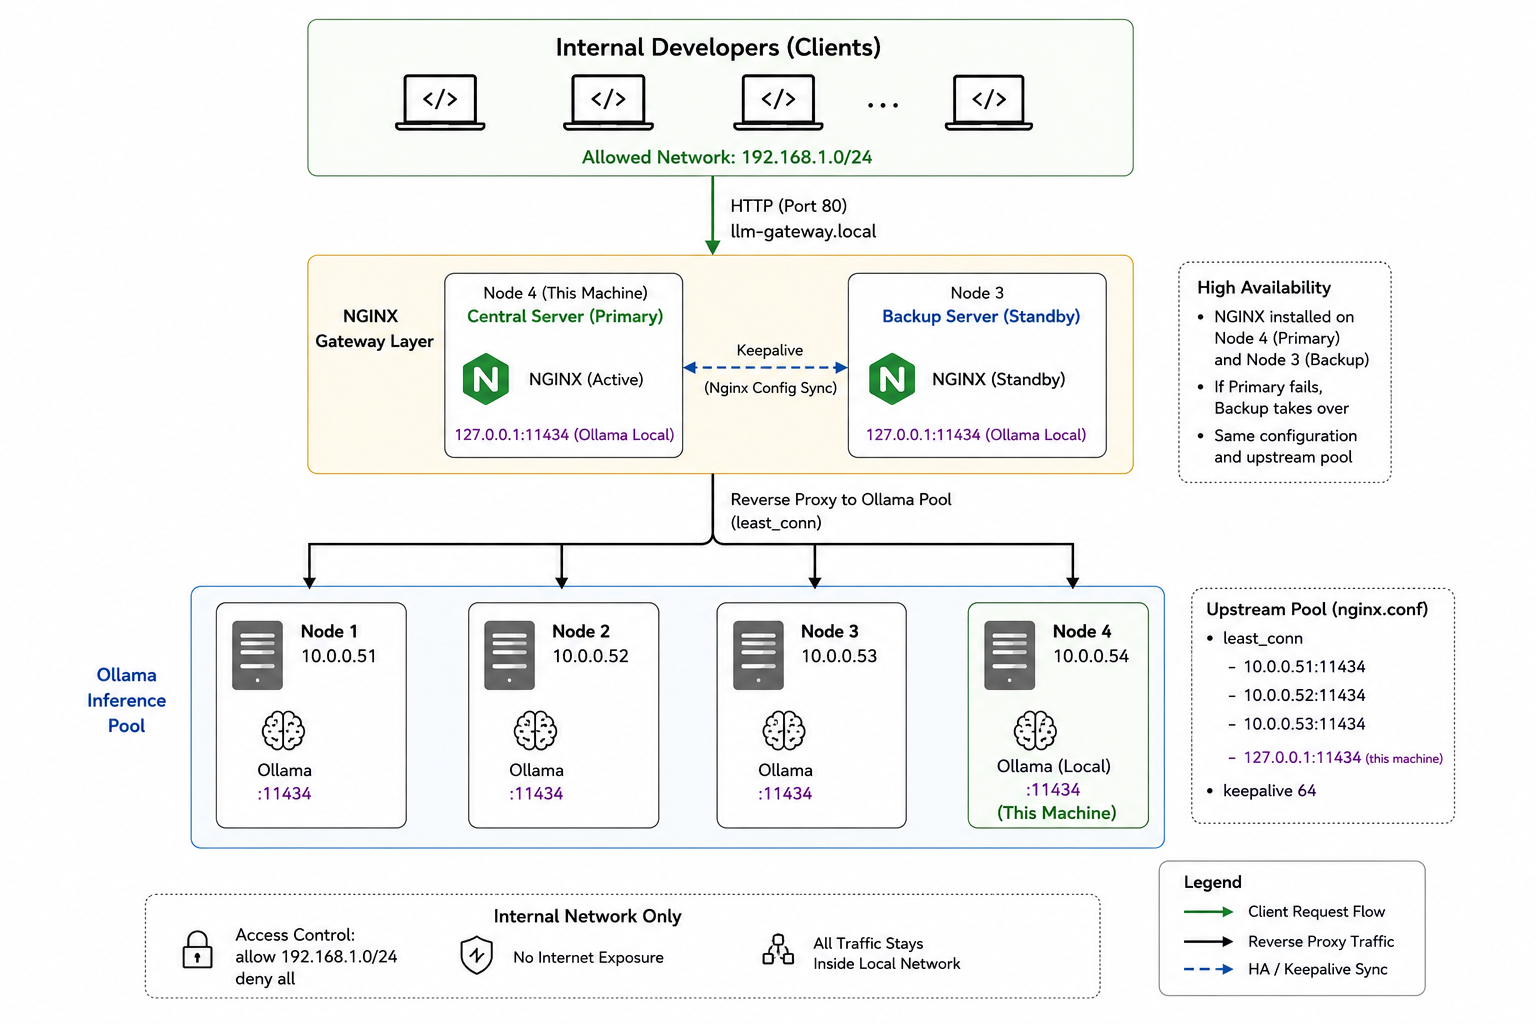

```yaml
# nginx.conf for both central and backup server, mirrored & managed by Keepalived

upstream ollama_pool {
    least_conn; # send requests to the least busy server
    server 10.0.0.51:11434 max_fails=2 fail_timeout=30s;
    server 10.0.0.52:11434 max_fails=2 fail_timeout=30s;
    server 10.0.0.53:11434 max_fails=2 fail_timeout=30s;
    server 127.0.0.1:11434 max_fails=2 fail_timeout=30s;  # this machine
    keepalive 64;
}

server {
    listen 80;
    server_name llm-gateway.local;

    location / {
        proxy_pass http://ollama_pool;
        proxy_http_version 1.1;
        proxy_set_header Connection "";
        proxy_set_header Host localhost; # tell Ollama the request is from Host Header so that Ollama won't reject it
        
        proxy_buffering off;             # So that token stream sends out real time
        proxy_read_timeout 600s;         # It takes time if output text is a lot

        # access control
        allow 192.168.1.0/24;  # only we can use it 192.168.1.1 - 192.168.1.254
        deny all;              # all others get 403 Forbidden
    }
}
```

## Implementation Roadmap 

* Phase 1: Pilot & Validation
    * Single-node deployment for latency/accuracy testing
    * VS Code + Continue integration testing
    * Access control (192.168.1.0/24) and egress filtering for security
* Phase 2: High Availability & Scaling
    * Expand to 4-node compute cluster
    * Deploy redundant NGINX gateways
* Phase 3: Production Hardening
    * Traffic mirroring and audit logging

# Q & A